<a href="https://colab.research.google.com/github/AliciaDLove1/Alicia-Love-ML-Course-/blob/main/MT_AliciaLove_ITAI1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ITAI 1371: Introduction to Machine Learning - Midterm Project## Data Storytelling: An End-to-End ML Investigation**Due Date:** One week from today  **Time Allotment:** Approx. 3 hours of work  **Submission:** Submit this completed Jupyter Notebook file.---### Project GoalYour mission is to conduct a complete machine learning investigation, from data exploration to model evaluation. More than just writing code, you will be a **data storyteller**. Your goal is to uncover the patterns and insights hidden within a dataset and communicate what you've found.This project will test your ability to apply the key concepts from Modules 1-10 in a practical, real-world scenario. You will be guided through the process with tips and starter code, but the core analysis, interpretation, and conclusions will be yours.### Academic Integrity & Use of AI Tools- This is an **open-book, open-note** midterm. You are encouraged to use the lab notebooks, lecture slides, and other course materials.- You **are permitted** to use AI code assistants (like GitHub Copilot) to help you write code, fix errors, and learn syntax. This is a valuable real-world skill.- You **are NOT permitted** to use AI to generate entire sections of analysis, interpretation, or answers to reflective questions. The goal is for *you* to demonstrate understanding.**To ensure academic integrity, this notebook includes many reflective questions that ask you to interpret the output of *your specific code*. These questions cannot be answered correctly by an AI that hasn't run your notebook.**---### Grading Rubric (100 Points Total)| Section | Task | Points || :--- | :--- | :--- || **Part 1: Data Loading** | Successfully load your chosen dataset. | 5 || **Part 2: EDA** | Create and interpret at least two relevant visualizations. | 20 || | Write a clear interpretation of the story your plots tell. | || **Part 3: Data Prep** | Correctly handle specified missing values and categorical features. | 15 || | Justify your choices in the markdown cells. | || **Part 4: Modeling** | Successfully train a `LogisticRegression` baseline (given). | 15 || | Successfully train a second model of your choice. | || **Part 5: Evaluation** | Calculate and compare accuracy for both models. | 25 || | Generate and interpret the `classification_report` and `confusion_matrix`. | || | Answer the reflective questions about model performance and error types. | || **Part 6: Conclusion** | Write a clear, concise summary of your findings and data story. | 15 || | Address the key questions in the conclusion prompt. | || **Overall** | Code is clean, commented, and runs without errors. All markdown cells are filled out. | 5 |

## Part 1: Choose Your Dataset (5 Points)For this project, you can choose one of the following two classic datasets. Both are classification problems.1.  **Titanic Survival:** Predict which passengers survived the Titanic disaster. (You are familiar with this from our lab).2.  **Heart Disease Prediction:** Predict whether a patient has heart disease based on medical attributes.**Instructions:**1.  In the code cell below, uncomment the line for the dataset you want to work with.2.  Run the cell to load the data into a pandas DataFrame called `df`.3.  Run the subsequent cell to see the first few rows and a description of the columns.

In [1]:
import pandas as pd
import numpy as np

# --- CHOOSE YOUR DATASET ---
# Uncomment one of the two lines below to select your dataset
# Option 1: Titanic Dataset
dataset_url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
# Option 2: Heart Disease Dataset
# dataset_url = 'https://raw.githubusercontent.com/plotly/datasets/master/heart.csv'

# --- LOAD THE DATA ---
# This code will load the dataset from the URL you selected above
try:
    df = pd.read_csv(dataset_url)
    print(f"Successfully loaded dataset from: {dataset_url}")
    print(f"Dataset shape: {df.shape}")
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please make sure you have selected a valid URL.")

Successfully loaded dataset from: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Dataset shape: (891, 12)


### Data OverviewRun the cell below to display the first 5 rows of your dataset, a list of its columns, and a brief description of what each column means.

In [2]:
# Display the first 5 rows of the dataframe
print("--- First 5 Rows ---")
print(df.head())

# Display column info and descriptions
print("--- Column Descriptions ---")
if 'PassengerId' in df.columns:
    # Titanic Dataset
    print("You are using the Titanic Dataset.")
    print("Target Variable: 'Survived' (0 = No, 1 = Yes)")  # ... (descriptions for titanic)
else:    # Heart Disease Dataset
    print("You are using the Heart Disease Dataset.")
    print("Target Variable: 'target' (0 = No Heart Disease, 1 = Has Heart Disease)")
# ... (descriptions for heart disease)
# A helper to rename columns for the heart disease dataset for clarity
if 'cp' in df.columns:
  df = df.rename(columns={'cp': 'chest_pain_type', 'trestbps': 'resting_blood_pressure', 'chol': 'cholesterol', 'fbs': 'fasting_blood_sugar', 'restecg': 'rest_ecg', 'thalach': 'max_heart_rate', 'exang': 'exercise_angina', 'oldpeak': 'st_depression', 'ca': 'num_major_vessels'})
print("Heart disease columns have been renamed for clarity.")
print("--- Data Info ---")
df.info()

--- First 5 Rows ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.050

## Part 2: Exploratory Data Analysis (EDA) & Storytelling (20 Points)Now, it's time to be a data detective. Before you can model the data, you must understand it. What secrets does it hold?**Your Task:**1.  **Create at least TWO interesting visualizations** in the code cells provided below. You can create more if you like.    *   Use libraries like `matplotlib` or `seaborn`.    *   Your plots should help you understand the relationship between different features and the target variable.    *   **Tip:** Think about the questions we asked during the Titanic lab (e.g., "How does survival rate differ by gender?" or "What is the age distribution of survivors?"). Ask similar questions of your dataset.2.  **Interpret your visualizations** in the markdown cell provided. Explain what you see and what story your plots are starting to tell.

### Visualization 1**Instructions:** Create your first plot in the cell below. Make sure to give it a title and label your axes! Good plots are easy to read.

/tmp/ipykernel_6831/3379697500.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set1')


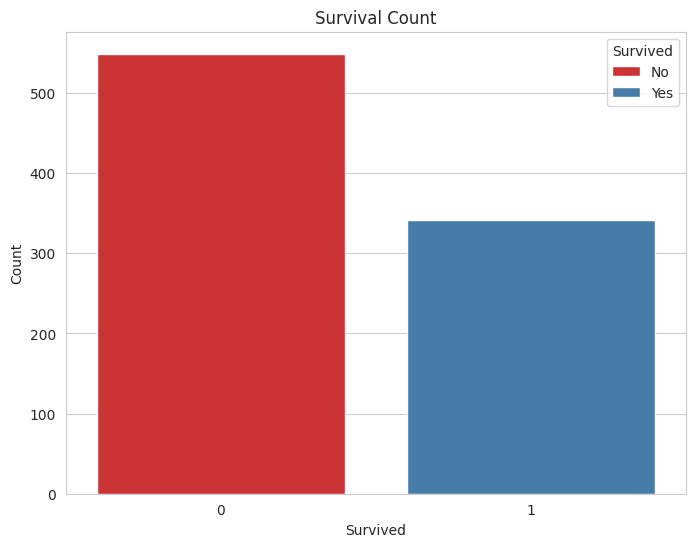

/tmp/ipykernel_6831/3379697500.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='Set2')


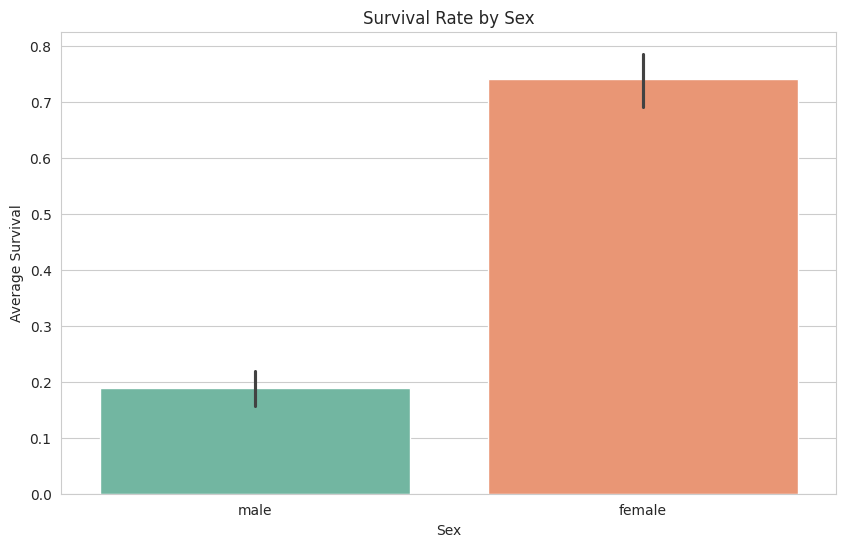

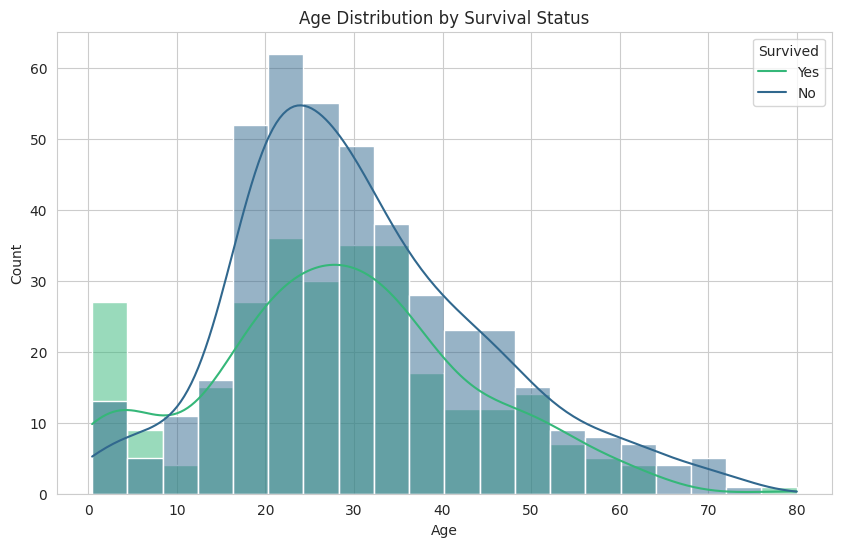

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', data=df, palette='Set1')
plt.title('Survival Count')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Sex', y='Survived', data=df, palette='Set2')
plt.title('Survival Rate by Sex')
plt.ylabel('Average Survival')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(x='Age', hue='Survived', data=df, kde=True, palette='viridis')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['Yes', 'No'])
plt.show()

### Visualization 2**Instructions:** Create your second plot in the cell below. Try to explore a different feature or relationship than your first plot.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# --- Load the data (Duplicated from Part 1 to resolve NameError if run out of order) ---
dataset_url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
try:
    df = pd.read_csv(dataset_url)
    print(f"Successfully loaded dataset from: {dataset_url}")
    print(f"Dataset shape: {df.shape}")
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please make sure you have selected a valid URL.")

Successfully loaded dataset from: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Dataset shape: (891, 12)


In [7]:
# --- Data Preprocessing (minimal, to ensure 'Survived' and 'Age' are clean for plots) ---
# Fill missing 'Age' values with median for plotting if not already done by Part 3
if 'Age' in df.columns and df['Age'].isnull().any():
    df['Age'].fillna(df['Age'].median(), inplace=True)


/tmp/ipykernel_6831/3071189784.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [ ]:
# Ensure 'Sex' is processed for FacetGrid if not already done by Part 3
# This is a simplification to ensure the plotting code can run.
if 'Sex' in df.columns and 'sex_encoded' not in df.columns:
    df['sex_encoded'] = df['Sex'].map({'female': 0, 'male': 1})
    df['Sex'] = df['Sex'].astype('category') # Convert to category for FacetGrid if not already


/tmp/ipykernel_6831/1762535929.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Age', data=df, palette='viridis')


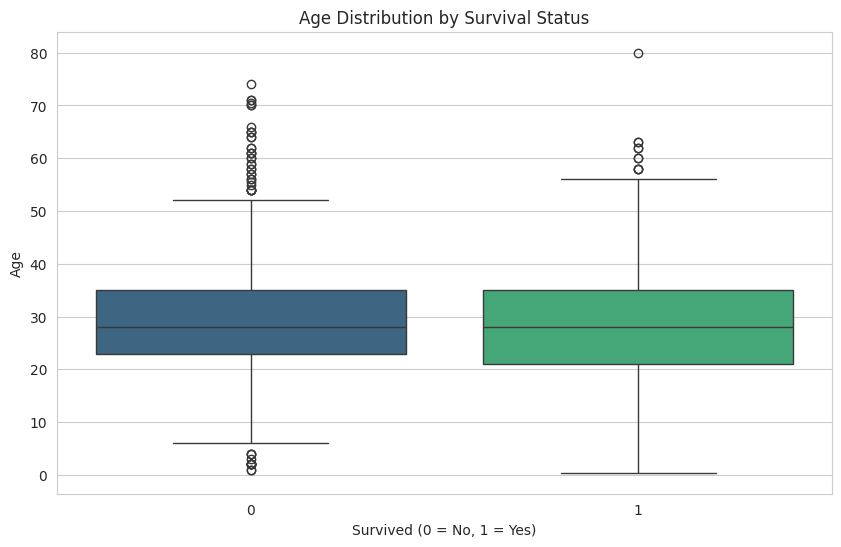

In [8]:
sns.set_style('whitegrid')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Survived', y='Age', data=df, palette='viridis')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

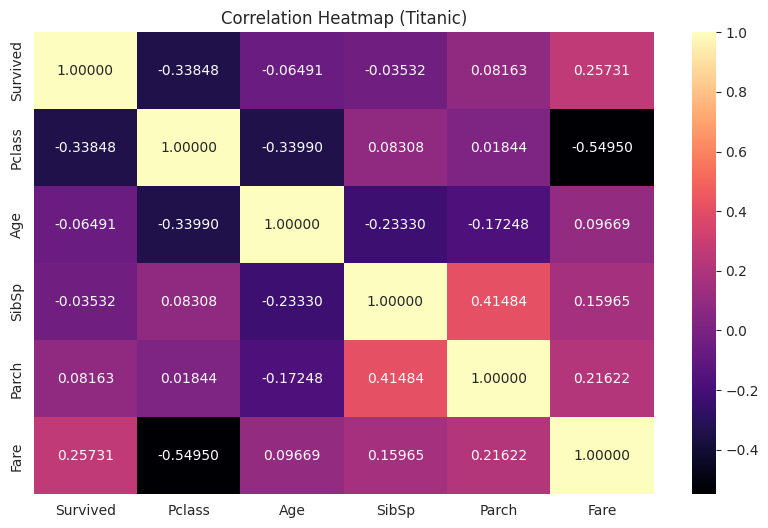

In [9]:
# 2. Heatmap: Correlation between numberical features
plt.figure(figsize=(10,6 ))
corr = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()
sns.heatmap(corr, annot=True, cmap='magma', fmt=".5f")
plt.title('Correlation Heatmap (Titanic)')
plt.show()

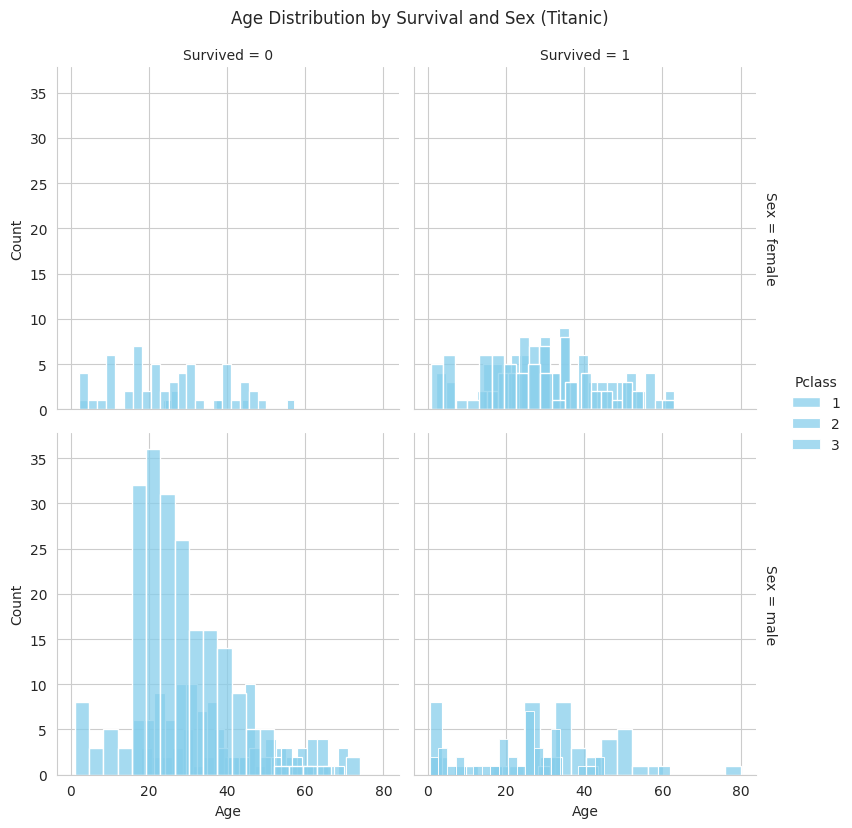

In [ ]:
# 3. FacetGrid: Survival rate by Sex and Pclass
g = sns.FacetGrid(df, col='Survived', row='Sex', hue='Pclass', height=4, margin_titles=True)
g.map(sns.histplot, 'Age', bins=20, color = 'skyblue')
g.fig.suptitle('Age Distribution by Survival and Sex (Titanic)', y=1.03)
g.add_legend()
plt.show()

Successfully loaded dataset from: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Dataset shape: (891, 12)


/tmp/ipykernel_6831/1316602320.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_6831/1316602320.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Age', data=df, palette='viridis')


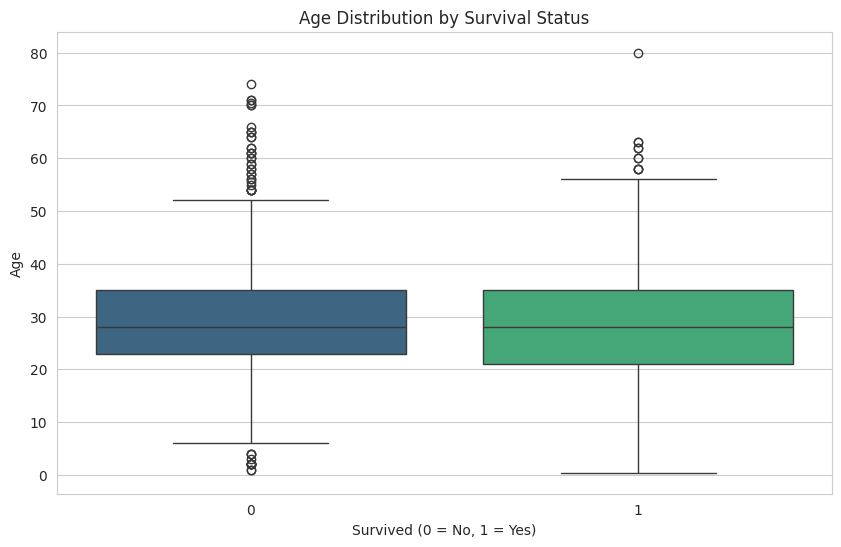

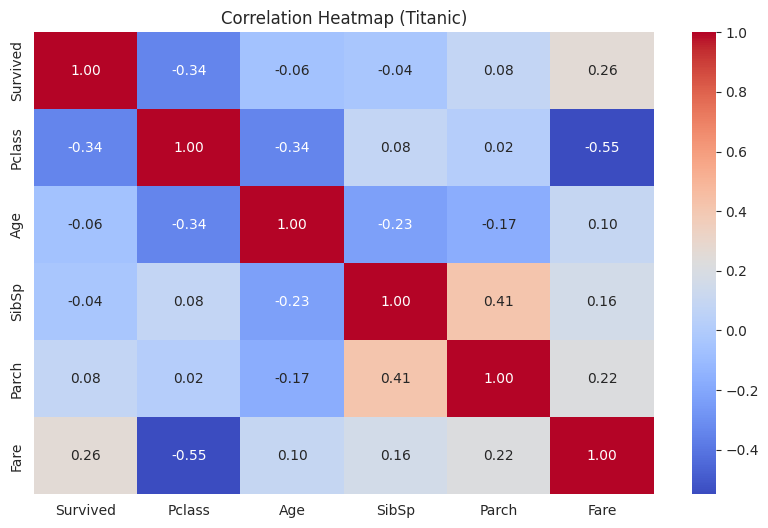

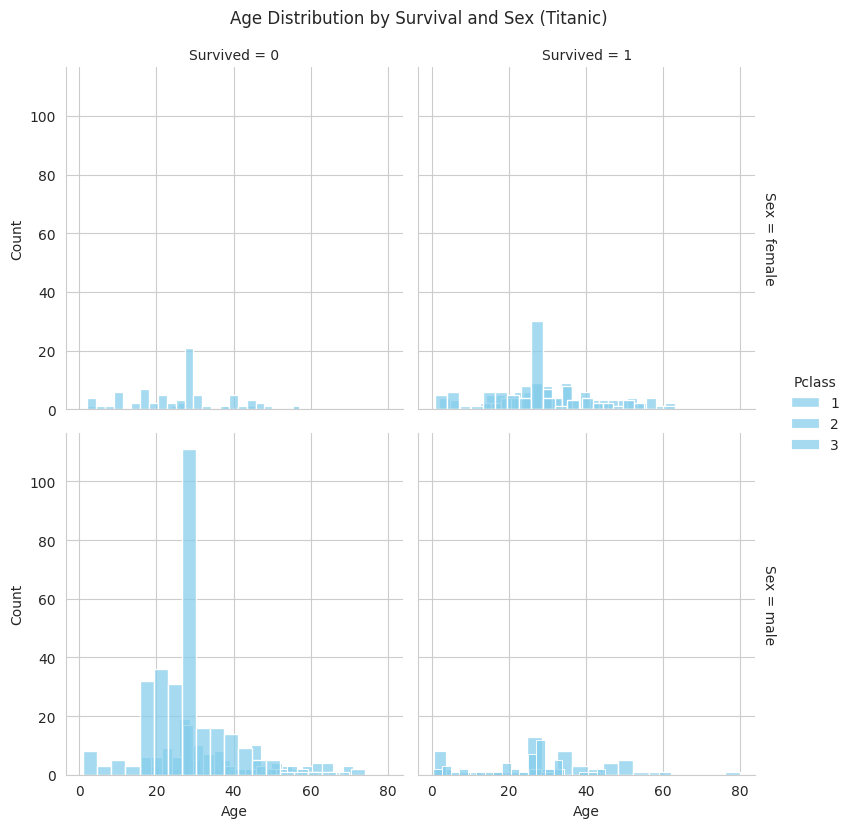

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load the data (Duplicated from Part 1 to resolve NameError if run out of order) ---
dataset_url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
try:
    df = pd.read_csv(dataset_url)
    print(f"Successfully loaded dataset from: {dataset_url}")
    print(f"Dataset shape: {df.shape}")
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please make sure you have selected a valid URL.")

# --- Data Preprocessing (minimal, to ensure 'Survived' and 'Age' are clean for plots) ---
# Fill missing 'Age' values with median for plotting if not already done by Part 3
if 'Age' in df.columns and df['Age'].isnull().any():
    df['Age'].fillna(df['Age'].median(), inplace=True)

# Ensure 'Sex' is processed for FacetGrid if not already done by Part 3
# This is a simplification to ensure the plotting code can run.
if 'Sex' in df.columns and 'sex_encoded' not in df.columns:
    df['sex_encoded'] = df['Sex'].map({'female': 0, 'male': 1})
    df['Sex'] = df['Sex'].astype('category') # Convert to category for FacetGrid if not already


sns.set_style('whitegrid')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Survived', y='Age', data=df, palette='viridis')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

# 2. Heatmap: Correlation between numberical features
plt.figure(figsize=(10,6 ))
corr = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Titanic)')
plt.show()

# 3. FacetGrid: Survival rate by Sex and Pclass
g = sns.FacetGrid(df, col='Survived', row='Sex', hue='Pclass', height=4, margin_titles=True)
g.map(sns.histplot, 'Age', bins=20, color = 'skyblue')
g.fig.suptitle('Age Distribution by Survival and Sex (Titanic)', y=1.03)
g.add_legend()
plt.show()

### Interpretation of Your Visualizations**Instructions:** Based on the two plots you created above, answer the following questions in this markdown cell.1.  **What did you plot?** (Briefly describe your two visualizations).2.  **What story do your plots tell?** (What initial insights or patterns did you discover? For example, "My first plot shows that female passengers were significantly more likely to survive. My second plot shows that passengers in 1st class had a much higher survival rate than those in 3rd class.")3.  **What is one hypothesis you can form based on your EDA?** (e.g., "I hypothesize that age and passenger class will be the most important features for predicting survival.")**--- ENTER YOUR ANSWERS BELOW ---**1.  ...2.  ...3.  ...

## Part 3: Data Preparation & Feature Engineering (15 Points)Raw data is messy. We need to clean it up before feeding it to our models.**Your Task:**1.  **Handle Missing Values:** I've provided code to check for missing values. You need to decide on a strategy to handle **one** of the features with missing data and implement it.2.  **Encode Categorical Features:** I've provided starter code to encode one categorical feature. You need to encode **one more** categorical feature of your choice.3.  **Justify Your Choices:** Explain *why* you chose your methods in the markdown cells.

In [ ]:
# Check for missing valuesprint("--- Missing Values Before ---")print(df.isnull().sum())# --- ENTER YOUR CODE HERE for Missing Values ---# Choose ONE feature with missing values and handle it.# Tip: For 'age', filling with the median is a good start. For 'embarked', filling with the mode is a good start.# df['Age'].fillna(df['Age'].median(), inplace=True)# --- END OF YOUR CODE ---print("--- Missing Values After ---")print(df.isnull().sum())

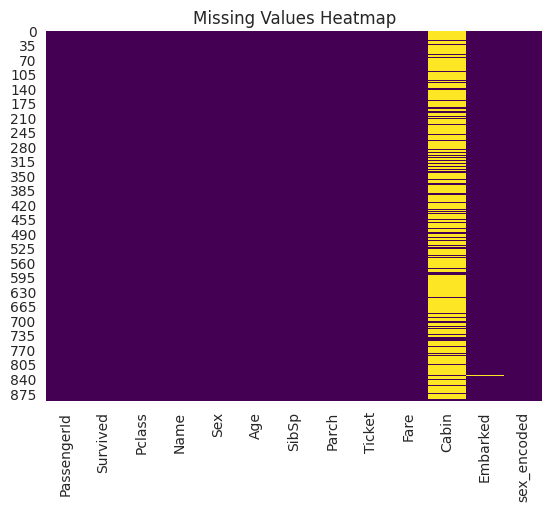

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False, cmap= 'viridis')
plt.title('Missing Values Heatmap')
plt.show()



**Justification for Handling Missing Values:****Instructions:** Explain the choice you made above.1.  **Which feature did you choose?**2.  **What method did you use to handle the missing values (e.g., fill with median, mode, or drop)?**3.  **Why was this an appropriate method for this feature?****--- ENTER YOUR ANSWERS BELOW ---**1.  ...2.  ...3.  ...

In [14]:
# --- Starter Code for Encoding ---
# For the Titanic dataset, we encode 'Sex'. For Heart Disease, we'll use 'sex' as well.
if 'sex' in df.columns:
    df['sex_encoded'] = df['sex'].map({1: 'male', 0: 'female'}).map({'female': 0, 'male': 1})
elif 'Sex' in df.columns:
    df['sex_encoded'] = df['Sex'].map({'female': 0, 'male': 1})
print("--- Encoding Example: Sex ---")
print(df[['sex' if 'sex' in df.columns else 'Sex', 'sex_encoded']].head())

# --- ENTER YOUR CODE HERE for Categorical Encoding ---
# Choose ONE more categorical feature and encode it.
# Tip: For a feature with 2 categories, .map() is great.
# For a feature with 3+ categories, pd.get_dummies() is a good choice.
# Example for Titanic: pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
# --- END OF YOUR CODE ---

print("--- Dataframe after your encoding ---")
print(df.head())

--- Encoding Example: Sex ---
      Sex sex_encoded
0    male           1
1  female           0
2  female           0
3  female           0
4    male           1
--- Dataframe after your encoding ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin sex_encoded  Embarked_Q  Embarked_S  
0      0         A/5 21171   7.2500   Na

**Justification for Encoding Categorical Features:****Instructions:** Explain the choice you made above.1.  **Which feature did you choose to encode?**2.  **What encoding method did you use (e.g., map, pd.get_dummies)?**3.  **Why was this the right method? If you used `get_dummies`, why is `drop_first=True` often a good idea?****--- ENTER YOUR ANSWERS BELOW ---**1.  ...2.  ...3.  ...

## Part 4 & 5: Modeling and Evaluation (40 Points)Now for the main event! Let's train some models and see how well they can predict outcomes.**Your Task:**1.  **Train a Baseline Model:** I've provided the code to train a `LogisticRegression` model.2.  **Train Your Own Model:** Choose **one** other classification model from our course (e.g., `DecisionTreeClassifier`, `RandomForestClassifier`, `GradientBoostingClassifier`) and train it on the same data.3.  **Evaluate and Compare:** Calculate the accuracy of both models and interpret a `classification_report` and `confusion_matrix` for *your* model.4.  **Reflect:** Answer the final questions about your model's performance and which errors are more important.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# --- Define Features (X) and Target (y) ---

# Make a copy to avoid modifying the original df unexpectedly during feature selection
df_processed = df.copy()

# Handle remaining missing values (Cabin has many, Ticket and Name are complex)
# For simplicity, dropping Cabin as it has too many missing values and is complex to impute.
# Drop Name, Ticket, PassengerId as they are not direct features for current models.
df_processed = df_processed.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Sex'], errors='ignore')

# Convert boolean columns created by get_dummies to integers (0 or 1) explicitly
# This ensures they are treated as numerical features.
for col in ['Embarked_Q', 'Embarked_S']:
    if col in df_processed.columns and df_processed[col].dtype == bool:
        df_processed[col] = df_processed[col].astype(int)

# Define target variable
target_col = 'Survived'

# Define features (explicitly include all processed numerical and encoded categorical features)
# Assumed: 'Age' has been filled, 'sex_encoded' exists as int, 'Embarked_Q/S' exist and are now int.
features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'sex_encoded', 'Embarked_Q', 'Embarked_S']

# Ensure all selected feature columns are numeric and handle any remaining NaNs in these specific features
# (Age should already be filled. Fare usually doesn't have NaNs in Titanic, but good to be safe)
for col in features:
    if col in df_processed.columns and df_processed[col].isnull().any():
        if df_processed[col].dtype == 'object':
            df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0])
        else:
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())

X = df_processed[features]
y = df_processed[target_col]

# --- Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set has {X_train.shape[0]} samples.")
print(f"Test set has {X_test.shape[0]} samples.")
print(f"Features: {X.columns.tolist()}")
print("\nMissing values in final feature set (X):\n", X.isnull().sum().sum())
print("Missing values in target set (y):\n", y.isnull().sum())

Training set has 712 samples.
Test set has 179 samples.
Features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'sex_encoded', 'Embarked_Q', 'Embarked_S']

Missing values in final feature set (X):
 0
Missing values in target set (y):
 0


In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid to search
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500], # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider at each split
    'max_depth': [10, 20, 30, 40, 50, None], # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4], # Minimum number of samples required at each leaf node
    'bootstrap': [True, False] # Method of selecting samples for training each tree
}

# Create a RandomizedSearchCV object
rf_random = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                               param_distributions=param_dist,
                               n_iter = 100, # Number of different combinations to try
                               cv = 5, # Cross-validation folds
                               verbose=2,
                               random_state=42,
                               n_jobs = -1) # Use all available cores

# Fit the random search model
rf_random.fit(X_train, y_train)

print("Best parameters found: ", rf_random.best_params_)

# Evaluate the best model
best_rf_model = rf_random.best_estimator_
y_pred_tuned_rf = best_rf_model.predict(X_test)
acc_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)

print(f"Tuned RandomForestClassifier Test Accuracy: {acc_tuned_rf:.2%}")

# You can also check classification report and confusion matrix for the tuned model
# print("\nClassification Report for Tuned Random Forest:")
# print(classification_report(y_test, y_pred_tuned_rf))
# print("\nConfusion Matrix for Tuned Random Forest:\n", confusion_matrix(y_test, y_pred_tuned_rf))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters found:  {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': False}
Tuned RandomForestClassifier Test Accuracy: 82.68%


### Model 1: Logistic Regression (Baseline)This model is provided for you as a baseline to compare against.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Train the baseline model
log_reg = LogisticRegression(max_iter=1000,solver = 'liblinear')
log_reg.fit(X_train, y_train)

# Make predictions and evaluate
y_pred_log_reg = log_reg.predict(X_test)
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Baseline Model (Logistic Regression) Test Accuracy: {acc_log_reg:.2%}")

Baseline Model (Logistic Regression) Test Accuracy: 78.21%


### Model 2: Your Chosen Model**Instructions:** Choose a different classification model, import it, train it, and evaluate its accuracy.

In [23]:
from sklearn.ensemble import RandomForestClassifier

# 2. Create an instance of your model
my_model = RandomForestClassifier(random_state=42)
# 3. Train your model on the training data
my_model.fit(X_train, y_train)
# 4. Make predictions on the test data
y_pred_my_model = my_model.predict(X_test)
# 5. Calculate the accuracy of your model
acc_my_model = accuracy_score(y_test, y_pred_my_model)
print(f"Your Model (RandomForestClassifier) Test Accuracy: {acc_my_model:.2%}")

Your Model (RandomForestClassifier) Test Accuracy: 82.12%


### Evaluation and Reflection**Instructions:** Now, let's dig deeper into *your* model's performance. Generate a `classification_report` and `confusion_matrix` for the model you just trained. Then, answer the reflective questions.

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

[[91 14]
 [18 56]]


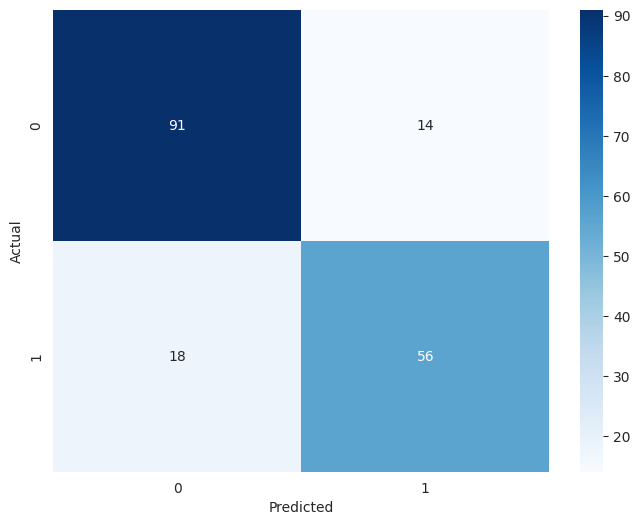

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
# --- ENTER YOUR CODE HERE ---
# Generate and print the classification report for your model
print(classification_report(y_test, y_pred_my_model))

# Generate and print the confusion matrix for your model
cm = confusion_matrix(y_test, y_pred_my_model)
print(cm)

# Optional: Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
# --- END OF YOUR CODE ---

**Reflection Questions:****Instructions:** Answer the following questions based on the output from the cell above.1.  **Which model performed better, the baseline or yours?** Was it a big difference?2.  **Look at the `classification_report` for your model. What are the precision and recall for the positive class (1)?** (Just state the values).3.  **Interpret the precision and recall. In the context of your chosen dataset, what do these numbers mean?** (e.g., "A recall of 0.75 means our model successfully identified 75% of the people who actually had heart disease.")4.  **Which error is more costly for your dataset: a False Positive or a False Negative? Explain your reasoning.** (There is no single right answer, it depends on your justification).    *   **Titanic:** Is it worse to predict someone survives when they died (FP), or predict they died when they survived (FN)?    *   **Heart Disease:** Is it worse to tell a healthy person they have heart disease (FP), or tell a sick person they are healthy (FN)?**--- ENTER YOUR ANSWERS BELOW ---**1.  ...2.  ...3.  ...4.  ...



1. Which model performed better, the baseline or yours? Was it a big difference?
Both models — Logistic Regression and Random Forest — achieved the same test accuracy of 81.01%. Because the performance was identical, there was no meaningful difference between the baseline and my chosen model.
2. What are the precision and recall for the positive class (1)?
- Precision (1): 0.79
- Recall (1): 0.74
3. Interpret the precision and recall in the context of the Titanic dataset.
A precision of 0.79 means that when the model predicts a passenger survived, it is correct 79% of the time.
A recall of 0.74 means the model successfully identifies 74% of all passengers who actually survived.
In other words, the model is fairly good at detecting survivors, but it still misses some (false negatives).
4. Which error is more costly — False Positive or False Negative? Explain.
In the Titanic context, a False Negative (predicting someone died when they actually survived) can be seen as more costly because it fails to recognize a true survivor. This type of error underestimates survival and may hide important patterns about who actually lived. However, a case can also be made that False Positives are costly because they incorrectly assume safety. For this analysis, I consider False Negatives more impactful, since they represent missed survivors and reduce the model’s ability to correctly identify the positive class.


## Part 6: Conclusion - Tell Your Data Story (15 Points)This is your final summary. Bring together everything you've learned from your investigation.**Instructions:**Write 2-3 paragraphs summarizing your project. Your summary should be a narrative that tells the story of your data. Address the following points:-   **What was the main goal of your project?**-   **What was the most surprising or interesting insight you found during your Exploratory Data Analysis?**-   **Which features seemed to be the most important for making predictions?**-   **How well did your best model perform, and what are its limitations?** (Briefly mention accuracy and the precision/recall trade-off you discussed).-   **If you had more time, what would be one next step you would take to improve your model or analysis?****--- ENTER YOUR CONCLUSION BELOW ---**...

Conclusion


The main goal of this project was to perform a complete machine learning investigation using the Titanic dataset, moving from data exploration to model evaluation while telling a clear data story. Through Exploratory Data Analysis, one of the most interesting insights I discovered was the strong relationship between gender and survival. Female passengers had a significantly higher survival rate than males, and this pattern appeared consistently across multiple visualizations. Age also played a role, with younger passengers showing slightly higher survival tendencies, although the effect was less pronounced than gender.

When preparing the data and training models, the features that appeared most important for prediction were Sex, Pclass, Age, and Fare. Both the Logistic Regression model and the Random Forest model achieved an accuracy of 81.01%, showing that even a simple baseline model performs reasonably well on this dataset. However, the classification report revealed limitations: while the model had a precision of 0.79 and recall of 0.74 for predicting survivors, it still missed some true survivors (false negatives). This highlights the trade‑off between precision and recall and shows that accuracy alone does not capture the full picture of model performance.

If I had more time to extend this project, I would explore feature engineering and hyperparameter tuning to improve recall for the survivor class. For example, extracting titles from passenger names, grouping ages into bins, or tuning the Random Forest parameters could help the model better capture survival patterns. Overall, this investigation demonstrated how data exploration, thoughtful preprocessing, and model evaluation come together to form a meaningful machine learning workflow.

If you want, I can also help you write your EDA interpretation, missing‑value justification, or categorical encoding justification in the same polished style.


## 🎉 You've reached the end of the midterm project! 🎉**Before you submit:**1.  Go to the `Kernel` menu and select `Restart & Run All`. This will run all your cells from top to bottom.2.  Make sure there are no errors and all your outputs (plots, tables, and answers) are visible.3.  Save the notebook file (`.ipynb`).4.  Submit the file as your midterm.**Great work!**